<a href="https://colab.research.google.com/github/MariethDataSc/ClassActivities_Mastery/blob/main/Actividad5ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ciberseguridad: Identificación de Perfiles de Red y Detección de Intrusiones mediante Aprendizaje No Supervisado
**Universidad Técnica de Manabí — Maestría en Ciencia de Datos y Máquinas de Aprendizaje**
**Asignatura:** Machine Learning
**Estudiante:** Ing. Madelayne Loor Vera
---

## Objetivo

Desarrollar un pipeline analítico no supervisado para procesar registros de tráfico de red corporativa (logs), extraer patrones de comportamiento de los usuarios e identificar actividades maliciosas ocultas o exfiltración de datos, fundamentando técnicamente cada decisión algorítmica.
## Contexto del problema

El equipo de seguridad informática ha capturado miles de conexiones de red (duración, bytes enviados/recibidos, intentos de login fallidos, puertos utilizados). No existen etiquetas que indiquen qué tráfico es un ataque. Se debe agrupar el comportamiento normal por perfil (ej. tráfico pesado de video vs. consultas ligeras a bases de datos) y aislar las conexiones peligrosas.

**Dataset:** se utiliza el **NSL-KDD** (`KDDTrain+.txt`, 125,973 conexiones originales, sub-muestreadas a 8,000 para agilidad de cómputo), descargado de Kaggle (hassan06/nslkdd).

In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(42)


In [3]:
import kagglehub
path = kagglehub.dataset_download("hassan06/nslkdd")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nslkdd' dataset.
Path to dataset files: /kaggle/input/nslkdd


In [4]:
import os, glob

# Localiza KDDTrain+.txt dentro de la carpeta descargada por kagglehub
ruta_train = glob.glob(os.path.join(path, "**", "KDDTrain+.txt"), recursive=True)[0]
print(f"Archivo encontrado: {ruta_train}")

# Nombres oficiales de las 41 columnas del NSL-KDD + clase + dificultad ---
NSL_KDD_COLS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","class","difficulty"
]

# Carga y adaptación al esquema de variables
raw = pd.read_csv(ruta_train, names=NSL_KDD_COLS)
raw = raw.sample(n=8000, random_state=42).reset_index(drop=True)

df = pd.DataFrame({
    "duracion_seg": raw["duration"].astype(float),
    "bytes_enviados": raw["src_bytes"].astype(float),
    "bytes_recibidos": raw["dst_bytes"].astype(float),
    "logins_fallidos": raw["num_failed_logins"].astype(float),
    "puerto": raw["service"],
    "perfil_real": raw["class"].apply(lambda x: "Normal" if x == "normal" else f"Ataque:{x}")
})

print(df.shape)
df.head()


Archivo encontrado: /kaggle/input/nslkdd/KDDTrain+.txt
(8000, 6)


,duracion_seg,bytes_enviados,bytes_recibidos,logins_fallidos,puerto,perfil_real
0,0.0,36.0,0.0,0.0,domain_u,Normal
1,0.0,0.0,0.0,0.0,http,Ataque:neptune
2,0.0,0.0,0.0,0.0,pop_3,Ataque:neptune
3,0.0,0.0,0.0,0.0,private,Ataque:neptune
4,0.0,0.0,0.0,0.0,private,Ataque:portsweep


## 1. Análisis Exploratorio de Datos (EDA) y Preprocesamiento
### Análisis: distribuciones de variables de red

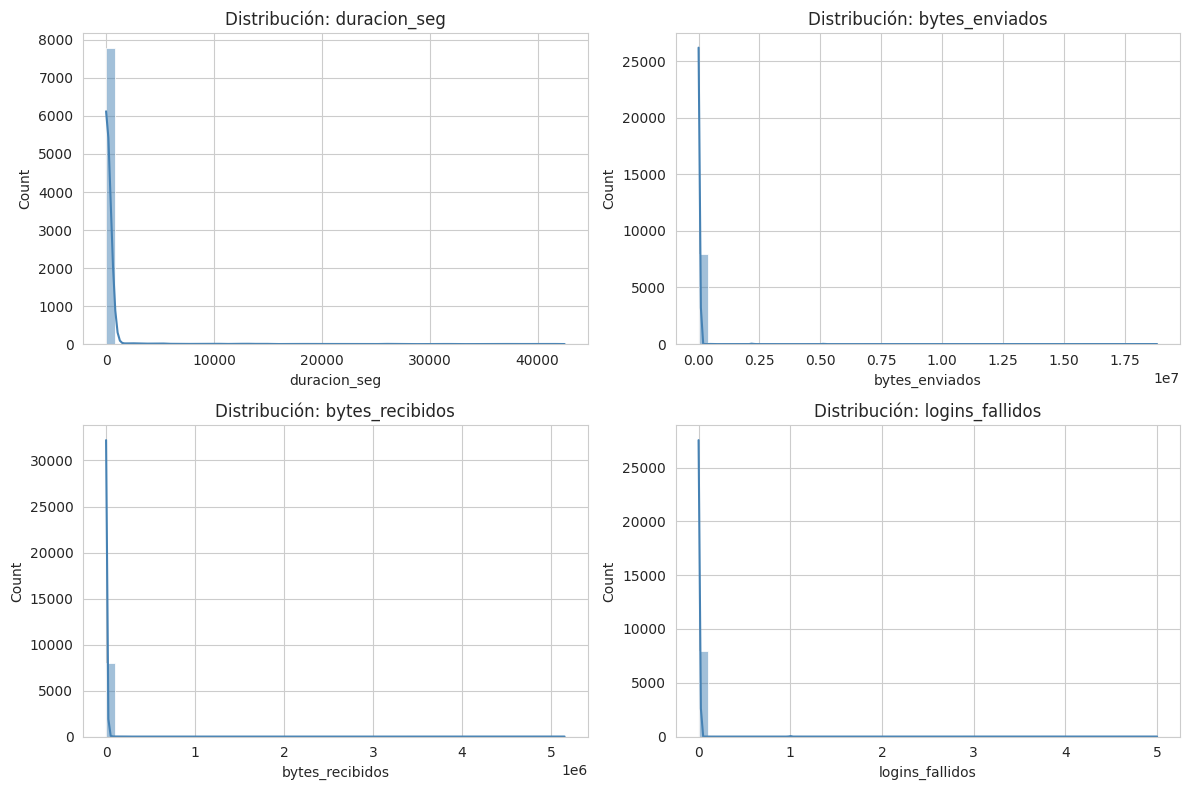

,duracion_seg,bytes_enviados,bytes_recibidos,logins_fallidos
count,8000.000000,8.000000e+03,8.000000e+03,8000.000000
mean,305.659250,1.168364e+04,2.424687e+03,0.002375
std,2602.496438,2.747229e+05,5.918960e+04,0.069785
min,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000
75%,0.000000,2.670000e+02,4.362500e+02,0.000000
max,42492.000000,1.882898e+07,5.153771e+06,5.000000


In [5]:
features_num = ["duracion_seg", "bytes_enviados", "bytes_recibidos", "logins_fallidos"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, features_num):
    sns.histplot(df[col], bins=50, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribución: {col}")
plt.tight_layout()
plt.show()

df[features_num].describe()


**dataset NSL-KDD, submuestra n=8000:** `bytes_enviados` tiene una media de **11,683** bytes pero una desviación estándar de **274,722** casi 24 veces la media y un máximo de **~18.8 millones de bytes**. Esto confirma una **asimetría positiva extrema**

### Preprocesamiento: transformación logarítmica y escalado

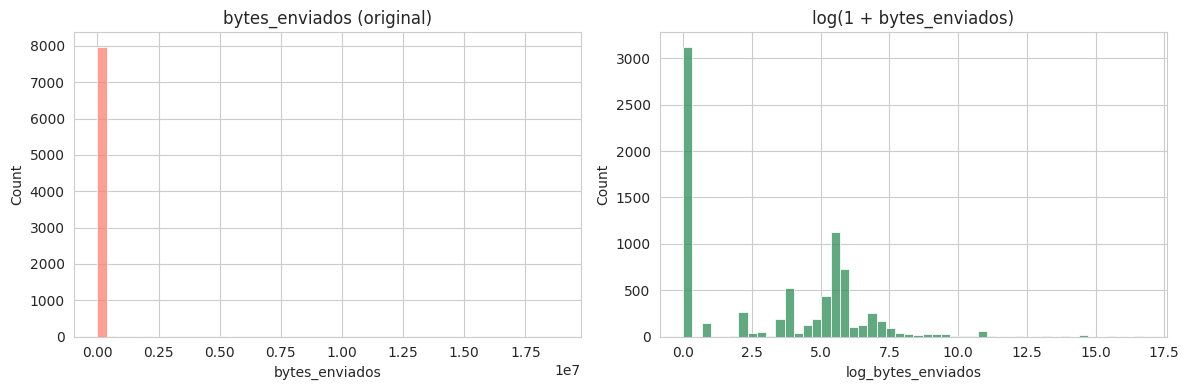

In [6]:
# Transformación logarítmica para suavizar la asimetría (log1p evita log(0))
df["log_bytes_enviados"] = np.log1p(df["bytes_enviados"])
df["log_bytes_recibidos"] = np.log1p(df["bytes_recibidos"])
df["log_duracion"] = np.log1p(df["duracion_seg"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["bytes_enviados"], bins=50, ax=axes[0], color="salmon")
axes[0].set_title("bytes_enviados (original)")
sns.histplot(df["log_bytes_enviados"], bins=50, ax=axes[1], color="seagreen")
axes[1].set_title("log(1 + bytes_enviados)")
plt.tight_layout()
plt.show()


In [7]:
# Variables finales para el modelado no supervisado
features_modelo = ["log_duracion", "log_bytes_enviados", "log_bytes_recibidos", "logins_fallidos"]

X_raw = df[features_modelo].values

scaler_std = StandardScaler()
scaler_rob = RobustScaler()

X_std = scaler_std.fit_transform(X_raw)
X_rob = scaler_rob.fit_transform(X_raw)

X = X_rob
print("Rango tras log1p, antes de escalar (log_bytes_enviados):", X_raw[:,1].min().round(2), "-", X_raw[:,1].max().round(2))
print("Rango después de RobustScaler (log_bytes_enviados):", X[:,1].min().round(2), "-", X[:,1].max().round(2))
print("Bytes originales (referencia, sin transformar):", df['bytes_enviados'].min(), "-", df['bytes_enviados'].max())


Rango tras log1p, antes de escalar (log_bytes_enviados): 0.0 - 16.75
Rango después de RobustScaler (log_bytes_enviados): -0.68 - 2.32
Bytes originales (referencia, sin transformar): 0.0 - 18828976.0


En el NSL-KDD, `bytes_enviados` alcanza **18.8 millones** mientras `logins_fallidos` casi nunca supera **5**. Si se usaran los algoritmos de distancia (K-Means, DBSCAN, Isolation Forest) directamente sobre estas magnitudes, la distancia euclidiana estaría dominada casi por completo por los bytes `logins_fallidos`. La transformación logarítmica comprime el rango de 0–18.8M a aproximadamente 0–16.75, y el escalado posterior lleva todas las variables a un rango comparable (-0.68 a 2.32 con RobustScaler). Se eligió **RobustScaler** sobre StandardScaler porque este dataset tiene outliers extremos por diseño, StandardScaler usaría la media y desviación estándar, ambas ya distorsionadas por esos mismos outliers, mientras que RobustScaler usa mediana e IQR, mucho más estables ante valores extremos.

## 2. Reducción de Dimensionalidad con PCA